<a href="https://colab.research.google.com/github/dhiraj089/CLEAR-TRACE/blob/main/Deep_Learning_Single_Layer_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Apply any two of the following learning algorithms to learn the parameters of the supervised single layer feed forward neural network.

Training with RMSprop GD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Adagrad GD...


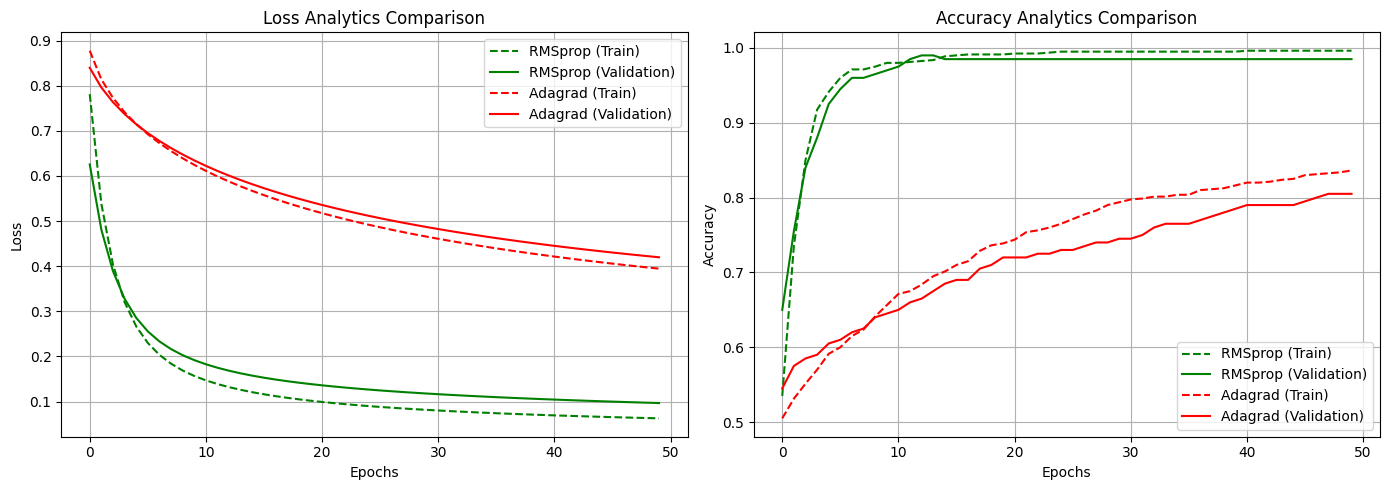


--- Final Performance Summary ---
RMSprop Final Val Accuracy: 0.9850
Adagrad Final Val Accuracy: 0.8050


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================================
# 1. GENERATE SYNTHETIC DATA FOR SUPERVISED LEARNING
# ==========================================

np.random.seed(42)
tf.random.set_seed(42)

# Create 1000 samples with 20 features for binary classification
X = np.random.randn(1000, 20).astype(np.float32)

# Generate labels using non-linear combination
true_weights = np.random.randn(20, 1)

y = (1 / (1 + np.exp(-np.dot(X, true_weights))) > 0.5).astype(np.float32)


# ==========================================
# 2. DEFINE SINGLE-LAYER NETWORK FUNCTION
# ==========================================

def build_single_layer_net():
    """Creates a supervised single-layer feed-forward neural network."""

    model = Sequential([
        Dense(units=1, activation='sigmoid', input_shape=(20,))
    ])

    return model


# ==========================================
# 3. APPLY ALGORITHM 1: RMSPROP OPTIMIZER
# ==========================================

print("Training with RMSprop GD...")

model_rmsprop = build_single_layer_net()

optimizer_rmsprop = tf.keras.optimizers.RMSprop(
    learning_rate=0.01
)

model_rmsprop.compile(
    optimizer=optimizer_rmsprop,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history_rmsprop = model_rmsprop.fit(
    X,
    y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)


# ==========================================
# 4. APPLY ALGORITHM 2: ADAGRAD OPTIMIZER
# ==========================================

print("Training with Adagrad GD...")

model_adagrad = build_single_layer_net()

optimizer_adagrad = tf.keras.optimizers.Adagrad(
    learning_rate=0.01
)

model_adagrad.compile(
    optimizer=optimizer_adagrad,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history_adagrad = model_adagrad.fit(
    X,
    y,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)


# ==========================================
# 5. PRESENT ANALYTICS OF THE WORK
# ==========================================

plt.figure(figsize=(14, 5))


# -------- Loss Comparison --------

plt.subplot(1, 2, 1)

plt.plot(
    history_rmsprop.history['loss'],
    label='RMSprop (Train)',
    color='green',
    linestyle='--'
)

plt.plot(
    history_rmsprop.history['val_loss'],
    label='RMSprop (Validation)',
    color='green'
)

plt.plot(
    history_adagrad.history['loss'],
    label='Adagrad (Train)',
    color='red',
    linestyle='--'
)

plt.plot(
    history_adagrad.history['val_loss'],
    label='Adagrad (Validation)',
    color='red'
)

plt.title('Loss Analytics Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)



# -------- Accuracy Comparison --------

plt.subplot(1, 2, 2)

plt.plot(
    history_rmsprop.history['accuracy'],
    label='RMSprop (Train)',
    color='green',
    linestyle='--'
)

plt.plot(
    history_rmsprop.history['val_accuracy'],
    label='RMSprop (Validation)',
    color='green'
)

plt.plot(
    history_adagrad.history['accuracy'],
    label='Adagrad (Train)',
    color='red',
    linestyle='--'
)

plt.plot(
    history_adagrad.history['val_accuracy'],
    label='Adagrad (Validation)',
    color='red'
)

plt.title('Accuracy Analytics Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()



# ==========================================
# 6. FINAL PERFORMANCE SUMMARY
# ==========================================

print("\n--- Final Performance Summary ---")

print(
    f"RMSprop Final Val Accuracy: "
    f"{history_rmsprop.history['val_accuracy'][-1]:.4f}"
)

print(
    f"Adagrad Final Val Accuracy: "
    f"{history_adagrad.history['val_accuracy'][-1]:.4f}"
)